In [3]:
from itertools import count

import pandas as pd
import numpy as np
import sklearn as skl

data = pd.read_csv('friction_place_data_2024.csv')
data.head()

,var.1,var.2,var.3,var.4,var.5,var.6,var.7,var.8,var.9,env.mbar,env.temp,env.hum,mat.2,mat.1,mat.3,Test.Result
0,0.573241,333.820198,22.988291,2,82,1.277546,2,21.443323,0.797869,995.143036,9,0.49,8.489696,14,154.875558,True
1,0.653573,280.281445,23.768343,2,89,1.246388,1,19.109389,-1.986141,1120.052376,9,0.30,6.717008,14,146.448811,False
2,0.632798,291.985294,21.991274,1,79,1.199507,2,19.667494,1.205539,934.854224,18,0.19,7.357749,20,112.030126,True
3,0.645263,269.346537,22.533471,2,88,1.232027,1,21.296443,1.415573,950.705889,16,0.29,6.498423,15,181.999714,False
4,0.649418,284.702282,22.029858,1,90,1.221646,1,20.991244,1.489283,1018.912404,18,0.47,3.609809,14,114.384407,False


In [4]:
tf_counts = data['Test.Result'].value_counts().to_numpy()
round((tf_counts[0] / (tf_counts[0] + tf_counts[1]) * 100), 1)

np.float64(58.8)

In [5]:
data['Test.Result'].value_counts()

Test.Result
False    120
True      84
Name: count, dtype: int64

In [6]:
true_data = data[data['Test.Result'] == True]
true_data

,var.1,var.2,var.3,var.4,var.5,var.6,var.7,var.8,var.9,env.mbar,env.temp,env.hum,mat.2,mat.1,mat.3,Test.Result
0,0.573241,333.820198,22.988291,2,82,1.277546,2,21.443323,0.797869,995.143036,9,0.49,8.489696,14,154.875558,True
2,0.632798,291.985294,21.991274,1,79,1.199507,2,19.667494,1.205539,934.854224,18,0.19,7.357749,20,112.030126,True
5,0.596787,286.427233,23.012245,2,82,1.190834,3,20.841394,-0.245496,965.574468,13,0.14,2.441738,17,166.278666,True
6,0.635568,273.171223,22.976584,2,77,1.213512,2,19.873665,1.572291,1028.417996,14,0.32,8.667039,12,160.646588,True
10,0.570471,274.616641,23.654827,2,73,1.257708,2,20.724917,2.657529,937.547442,10,0.53,9.769286,16,164.720964,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,0.596787,295.084515,22.087821,1,89,1.210007,2,20.124706,-1.052114,1101.336857,10,0.68,8.096781,15,174.890590,True
192,0.562161,288.201597,22.045827,2,80,1.240743,2,19.665618,0.136932,898.170337,9,0.33,6.399320,15,129.537265,True
198,0.589861,275.992110,22.090845,2,71,1.285964,3,19.466347,0.078283,1042.025462,8,0.69,3.409613,10,128.666577,True
200,0.653573,258.855037,22.999826,1,71,1.240224,3,21.472308,-0.405009,889.545493,18,0.52,3.371586,19,144.300896,True


In [7]:
round(true_data['mat.2'].mean(axis=0), 1)

np.float64(6.2)

In [8]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

In [9]:
data = pd.read_csv('friction_place_data_2024.csv')

train , test = train_test_split(data, test_size = 0.3, random_state = 123)

print(train.head())
print(test.head())


        var.1       var.2      var.3  var.4  var.5     var.6  var.7  \
182  0.569086  271.311094  22.465054      2     71  1.263248      1   
42   0.599557  285.745995  24.130101      2     71  1.279349      1   
121  0.657729  285.949767  24.527377      2     71  1.264294      3   
71   0.552465  297.580875  22.205889      2     73  1.209490      2   
82   0.634183  311.954212  23.244873      1     72  1.204187      1   

         var.8     var.9     env.mbar  env.temp  env.hum     mat.2  mat.1  \
182  21.592826 -1.195763   899.069691         9     0.52  5.722382     13   
42   20.341273  1.115950   979.816892        11     0.12  5.796118     14   
121  20.424331  0.894105   875.974642        15     0.16  5.879165     17   
71   21.163293  0.644398  1108.394078        11     0.22  6.861647     16   
82   21.589984 -1.305017   984.945272        20     0.38  7.069580     14   

          mat.3  Test.Result  
182  126.330111        False  
42   170.769478        False  
121  138.727321  

In [10]:
y_train = train['Test.Result']
X_train = train.drop('Test.Result', axis = 1)

In [11]:
y_test = test['Test.Result']
X_test = test.drop('Test.Result', axis = 1)

Lets create the training models

In [12]:
#Logistic regression
lr_model = LogisticRegression(max_iter = 1000, random_state=123)
lr_model.fit(X_train, y_train)

C:\Users\mikko\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",123
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mult

In [13]:
#Decision Tree
dtree = DecisionTreeClassifier(min_samples_leaf=10, random_state=123)
dtree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",123
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [14]:
#Random Forest
rf = RandomForestClassifier(n_estimators=1000, random_state=123)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [15]:
#Support Vector Machine
svm_model = SVC( probability=True, C=10, degree=5, gamma='auto', kernel='rbf', random_state=123)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",5
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'auto'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [16]:
# Neural Network Classifier
nnc = MLPClassifier(max_iter=20000, learning_rate='adaptive', hidden_layer_sizes=(10, 5), learning_rate_init=0.01,random_state=123)
nnc.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(10, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'adaptive'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",20000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",123


In [17]:
# Gradient Boosting Machine
gbm = GradientBoostingClassifier(n_estimators=1000, learning_rate=0.1, max_depth=5, min_samples_leaf=5, random_state=123)
gbm.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

Lets compare the accuracy scores with test data

In [18]:
from sklearn.metrics import accuracy_score
model_list = [
    ("Logistic Regression", lr_model),
    ("Decision Tree", dtree),
    ("Random Forest", rf),
    ("Support Vector Machine", svm_model),
    ("Neural Network", nnc),
    ("Gradient Boosting", gbm)
]

performance_data = []

for name, model in model_list:
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    performance_data.append({"Model": name, "Accuracy": accuracy})

results_df = pd.DataFrame(performance_data).sort_values(by="Accuracy", ascending=False)

print(results_df.to_string(index=False))

                 Model  Accuracy
         Random Forest  0.822581
         Decision Tree  0.806452
     Gradient Boosting  0.790323
   Logistic Regression  0.677419
        Neural Network  0.645161
Support Vector Machine  0.596774


In [19]:
from sklearn.metrics import confusion_matrix

specificity_data = []

for name, model in model_list:
    y_pred = model.predict(X_test)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()


    specificity = tn / (tn + fp)

    specificity_data.append({"Model": name, "Specificity": specificity})

specificity_df = pd.DataFrame(specificity_data).sort_values(by="Specificity", ascending=True)

print(specificity_df.to_string(index=False))

                 Model  Specificity
   Logistic Regression     0.756757
         Decision Tree     0.837838
     Gradient Boosting     0.891892
        Neural Network     0.945946
         Random Forest     0.972973
Support Vector Machine     1.000000


In [20]:
dtree.get_n_leaves()

np.int64(8)

AUC calculations

In [21]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

auc_data = []

for name, model in model_list:
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test)[:, 1]
    else:
        probs = model.decision_function(X_test)

    auc_val = roc_auc_score(y_test, probs)
    auc_data.append({"Model": name, "AUC": auc_val})


auc_df = pd.DataFrame(auc_data).sort_values(by="AUC", ascending=False)
print(auc_df.to_string(index=False))

                 Model      AUC
         Random Forest 0.875676
     Gradient Boosting 0.860541
         Decision Tree 0.832432
   Logistic Regression 0.725405
        Neural Network 0.682162
Support Vector Machine 0.662162


Random forest importance

In [28]:
importances = rf.feature_importances_
feature_names = X_train.columns

df_imp = pd.DataFrame({'Variable': feature_names, 'Importance': importances})
df_imp = df_imp.sort_values(by='Importance', ascending=False)

print(df_imp)

    Variable  Importance
12     mat.2    0.191747
6      var.7    0.175654
9   env.mbar    0.096440
2      var.3    0.068006
1      var.2    0.063361
7      var.8    0.054887
14     mat.3    0.054577
0      var.1    0.050475
8      var.9    0.047794
10  env.temp    0.046004
5      var.6    0.045326
11   env.hum    0.038081
4      var.5    0.037626
13     mat.1    0.024958
3      var.4    0.005064


In [25]:
significance = pd.DataFrame({'Variable': X_train.columns, 'Significance': dtree.feature_importances_})

significance = significance.sort_values(by='Significance', ascending=False)

print(significance)

    Variable  Significance
6      var.7      0.652378
12     mat.2      0.307263
9   env.mbar      0.040359
2      var.3      0.000000
3      var.4      0.000000
1      var.2      0.000000
0      var.1      0.000000
5      var.6      0.000000
4      var.5      0.000000
8      var.9      0.000000
7      var.8      0.000000
10  env.temp      0.000000
11   env.hum      0.000000
13     mat.1      0.000000
14     mat.3      0.000000


[Text(0.5, 0.9, 'x[6] <= 1.5\ngini = 0.486\nsamples = 142\nvalue = [83, 59]'),
 Text(0.3076923076923077, 0.7, 'x[12] <= 6.476\ngini = 0.221\nsamples = 71\nvalue = [62.0, 9.0]'),
 Text(0.40384615384615385, 0.8, 'True  '),
 Text(0.23076923076923078, 0.5, 'x[12] <= 4.649\ngini = 0.123\nsamples = 61\nvalue = [57, 4]'),
 Text(0.15384615384615385, 0.3, 'x[9] <= 980.084\ngini = 0.26\nsamples = 26\nvalue = [22, 4]'),
 Text(0.07692307692307693, 0.1, 'gini = 0.0\nsamples = 16\nvalue = [16, 0]'),
 Text(0.23076923076923078, 0.1, 'gini = 0.48\nsamples = 10\nvalue = [6, 4]'),
 Text(0.3076923076923077, 0.3, 'gini = 0.0\nsamples = 35\nvalue = [35, 0]'),
 Text(0.38461538461538464, 0.5, 'gini = 0.5\nsamples = 10\nvalue = [5, 5]'),
 Text(0.6923076923076923, 0.7, 'x[6] <= 2.5\ngini = 0.417\nsamples = 71\nvalue = [21, 50]'),
 Text(0.5961538461538461, 0.8, '  False'),
 Text(0.5384615384615384, 0.5, 'x[9] <= 971.255\ngini = 0.054\nsamples = 36\nvalue = [1, 35]'),
 Text(0.46153846153846156, 0.3, 'gini = 0.18\

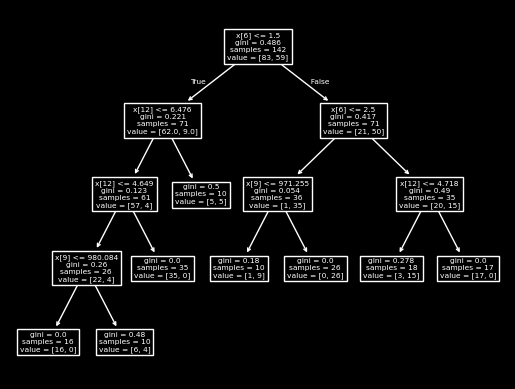

In [26]:
skl.tree.plot_tree(dtree)


In [29]:
X_train.head


<bound method NDFrame.head of         var.1       var.2      var.3  var.4  var.5     var.6  var.7  \
182  0.569086  271.311094  22.465054      2     71  1.263248      1   
42   0.599557  285.745995  24.130101      2     71  1.279349      1   
121  0.657729  285.949767  24.527377      2     71  1.264294      3   
71   0.552465  297.580875  22.205889      2     73  1.209490      2   
82   0.634183  311.954212  23.244873      1     72  1.204187      1   
..        ...         ...        ...    ...    ...       ...    ...   
17   0.596787  295.084515  22.087821      1     89  1.210007      2   
98   0.551080  283.427590  22.433839      2     76  1.177392      1   
66   0.541385  294.091824  22.242750      2     90  1.264631      1   
126  0.578781  272.856796  23.743889      2     83  1.206777      1   
109  0.677119  285.613899  22.334156      1     84  1.242072      1   

         var.8     var.9     env.mbar  env.temp  env.hum     mat.2  mat.1  \
182  21.592826 -1.195763   899.069691   

from sklearn.inspection import permutation_importance

for name, model in model_list:
    print(f"\n{'='*40}")
    print(f"Lasketaan tärkeyksiä mallille: {name}")
    print(f"{'='*40}")

    try:
        # Lasketaan permutation importance. n_repeats=5 nopeuttaa laskentaa (10 on tarkempi)
        tulos = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=123)

        # Luodaan DataFrame tuloksista
        tarkeydet = pd.DataFrame({
            'Muuttuja': X_test.columns,
            'Tärkeys_keskiarvo': tulos.importances_mean
        })

        # Järjestetään tärkeimmästä vähiten tärkeään ja suodatetaan nollat pois
        tarkeydet = tarkeydet.sort_values(by='Tärkeys_keskiarvo', ascending=False)
        tarkeydet = tarkeydet[tarkeydet['Tärkeys_keskiarvo'] > 0.001] # Näytetään vain merkittävät

        if tarkeydet.empty:
            print("Yksikään muuttuja ei noussut selvästi ylitse muiden (tärkeys > 0.001).")
        else:
            print(tarkeydet.head(10).to_string(index=False)) # Tulostetaan top 10

    except Exception as e:
        print(f"Virhe laskennassa mallille {name}: {e}")

In [35]:
import numpy as np

for name, model in model_list:
    print(f"\n--- {name} ---")

    # 1. Tarkistetaan, onko mallilla feature_importances_ (Puumallit)
    if hasattr(model, 'feature_importances_'):
        tarkeydet = pd.DataFrame({
            'Muuttuja': X_train.columns,
            'Tärkeys': model.feature_importances_
        }).sort_values(by='Tärkeys', ascending=False)
        print(tarkeydet.head(5).to_string(index=False))

    # 2. Tarkistetaan, onko mallilla coef_ (Lineaariset mallit, esim. Logistic Regression)
    elif hasattr(model, 'coef_'):
        # Lineaarisissa malleissa kertoimen itseisarvo (absoluuttinen arvo) kertoo tärkeyden
        tarkeydet = pd.DataFrame({
            'Muuttuja': X_train.columns,
            'Tärkeys (Itseisarvo)': np.abs(model.coef_[0])
        }).sort_values(by='Tärkeys (Itseisarvo)', ascending=False)
        print(tarkeydet.head(5).to_string(index=False))

    # 3. Mallit ilman sisäänrakennettua tärkeysmittaria (Neuroverkko, joidenkin kernelien SVM)
    else:
        print("Tällä mallilla ei ole sisäänrakennettua tärkeysmittaria.")
        print("Käytä tälle mallille permutation_importance -työkalua.")


--- Logistic Regression ---
Muuttuja  Tärkeys (Itseisarvo)
   var.7              1.107121
 env.hum              0.390391
   mat.2              0.387361
   var.9              0.346759
   var.3              0.300213

--- Decision Tree ---
Muuttuja  Tärkeys
   var.7 0.652378
   mat.2 0.307263
env.mbar 0.040359
   var.3 0.000000
   var.4 0.000000

--- Random Forest ---
Muuttuja  Tärkeys
   mat.2 0.191747
   var.7 0.175654
env.mbar 0.096440
   var.3 0.068006
   var.2 0.063361

--- Support Vector Machine ---
Tällä mallilla ei ole sisäänrakennettua tärkeysmittaria.
Käytä tälle mallille permutation_importance -työkalua.

--- Neural Network ---
Tällä mallilla ei ole sisäänrakennettua tärkeysmittaria.
Käytä tälle mallille permutation_importance -työkalua.

--- Gradient Boosting ---
Muuttuja  Tärkeys
   var.7 0.486604
   mat.2 0.287257
env.mbar 0.056489
env.temp 0.032233
   mat.3 0.026983


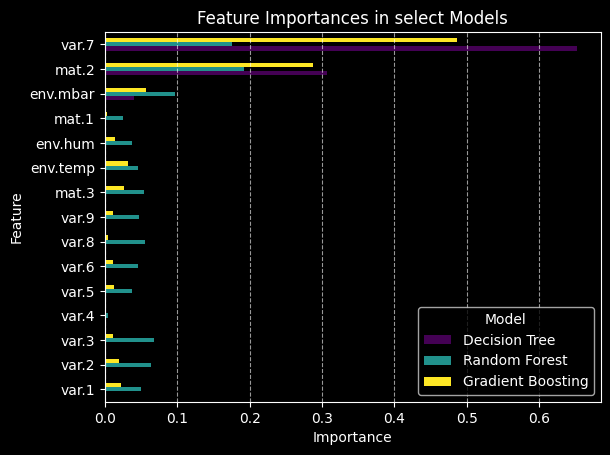

In [48]:
import matplotlib.pyplot as plt

# Assuming dtree, rf, and gbm models are already trained using X_train

# 1. Collect built-in feature importances into a DataFrame
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Decision Tree': dtree.feature_importances_,
    'Random Forest': rf.feature_importances_,
    'Gradient Boosting': gbm.feature_importances_
})

# 2. Simplify: Calculate total importance to filter out useless features
importance_df['Total_Importance'] = importance_df[['Decision Tree', 'Random Forest', 'Gradient Boosting']].sum(axis=1)

# Keep only features that have at least some importance (> 0) in any of the models
importance_df = importance_df[importance_df['Total_Importance'] > 0].copy()

# Drop the helper column as we don't want to plot it
importance_df.drop(columns=['Total_Importance'], inplace=True)

# 3. Sort the data (e.g., by Random Forest) for a cleaner look
importance_df = importance_df.sort_values(by='Decision Tree', ascending=True)

# Set 'Feature' as the index so pandas uses it for the y-axis labels
importance_df.set_index('Feature', inplace=True)

# 4. Plot the simplified grouped bar chart
importance_df.plot(kind='barh', colormap='viridis')

# 5. Format the chart with English labels
plt.title('Feature Importances in select Models')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.legend(title='Model')


plt.grid(axis='x', linestyle='--', alpha=0.6)


plt.show()

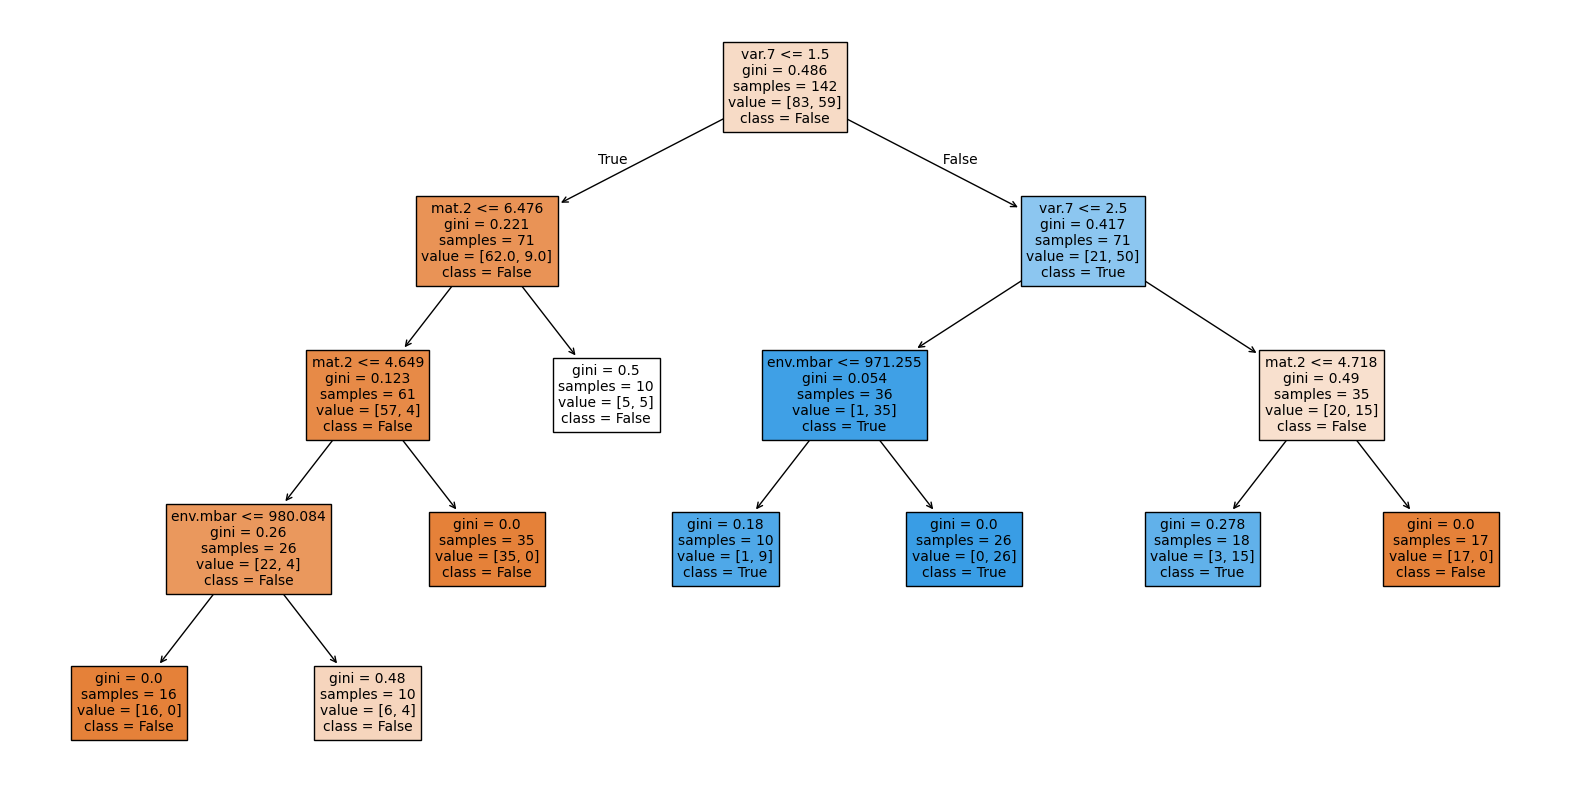

In [51]:
from sklearn.tree import DecisionTreeClassifier, plot_tree


plt.figure(figsize=(20,10))
plot_tree(dtree, filled=True, feature_names=X_train.columns, class_names=['False', 'True'], fontsize=10)
plt.show()